In [2]:
import numpy as np, xarray as xr, pandas as pd
import matplotlib.pyplot as plt


In [2]:
greenland = np.load('../data/GRE_mask.npy')

In [4]:

ds = xr.load_dataset('../data/sat1_0125.zarr')
ds

<xarray.Dataset> Size: 82MB
Dimensions:                  (lat: 180, lon: 360, spectral: 63)
Coordinates:
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 88.0 89.0
  * lon                      (lon) float64 3kB -180.0 -179.0 ... 178.0 179.0
  * spectral                 (spectral) int64 504B 0 1 2 3 4 ... 58 59 60 61 62
Data variables:
    spectral_radiance        (lat, lon, spectral) float32 16MB nan nan ... nan
    spectral_radiance_count  (lat, lon, spectral) int32 16MB 0 0 0 0 ... 0 0 0 0
    spectral_radiance_max    (lat, lon, spectral) float32 16MB 0.0 0.0 ... 0.0
    spectral_radiance_min    (lat, lon, spectral) float32 16MB inf inf ... inf
    spectral_radiance_std    (lat, lon, spectral) float32 16MB nan nan ... nan
    wavelength               (spectral) float32 252B nan nan nan ... 51.9 52.66
Attributes:
    description:  Gridded mean, std, count, min, max of spectral radiance bin...
    satellite:    sat1
    year_month:   2025-01

(168, 360) bool 573


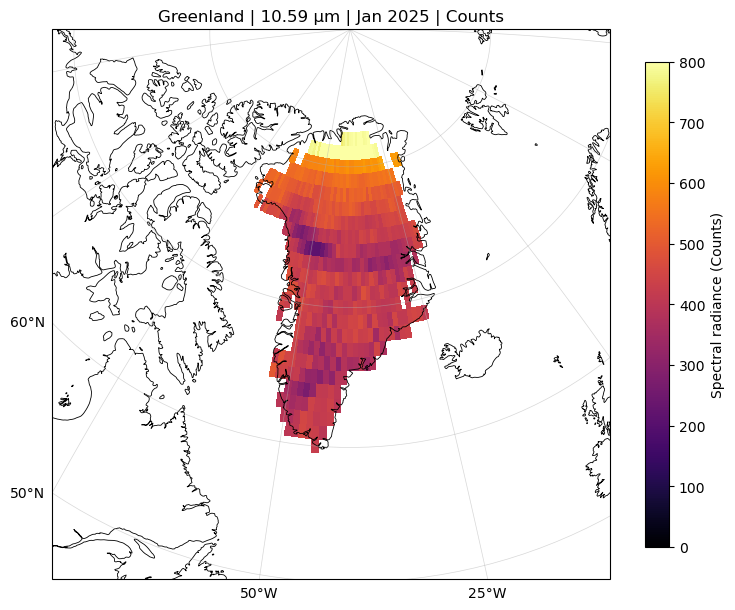

In [14]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- 1. Load the mask and check it matches the grid -------------------------
greenland = np.load('../data/GRE_mask.npy')
print(greenland.shape, greenland.dtype, greenland.sum())   # expect (180, 360)
n_lat, n_lon = greenland.shape
n_pad_total = 180 - n_lat
assert n_pad_total % 2 == 0, "asymmetric padding needed — check exact lat bounds"
n_pad = n_pad_total // 2   # rows to add on EACH side (6 if 168 -> 180)
greenland = np.pad(greenland, ((n_pad, n_pad), (0, 0)),
                        mode='constant', constant_values=0)
# If lon runs 0-360 instead of -180-180:   greenland = np.roll(greenland, 180, axis=1)
# If lat runs north->south:                greenland = greenland[::-1, :]

mask = xr.DataArray(
    greenland.astype(bool),
    dims=('lat', 'lon'),
    coords={'lat': ds.lat, 'lon': ds.lon},
    name='greenland_mask',
)
# mask.plot()          # sanity check: should light up ~60-84°N, 75-10°W
# plt.show()

# --- 2. Apply the mask ------------------------------------------------------
spec_num = 12
rad = ds.spectral_radiance_count.isel(spectral=spec_num)
rad_gre = rad.where(mask)            # everything outside Greenland -> NaN

# --- 3. Plot ----------------------------------------------------------------
fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.Orthographic(central_latitude=72, central_longitude=-40))
ax.set_extent([-75, -10, 50, 90], crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(ds.lon, ds.lat, rad_gre,
                     transform=ccrs.PlateCarree(),
                     cmap='inferno', vmin=0, vmax=800, shading='auto')
ax.coastlines(linewidth=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.right_labels = False
gl.top_labels = False
cbar = plt.colorbar(mesh, shrink=0.7, pad=0.05)
cbar.set_label('Spectral radiance (Counts)')
ax.set_title(f'Greenland | {ds.wavelength.values[spec_num]:.2f} µm | Jan 2025 | Counts')
plt.savefig('../gallery/trial_gre_counts.png', dpi=300, bbox_inches='tight')
plt.show()

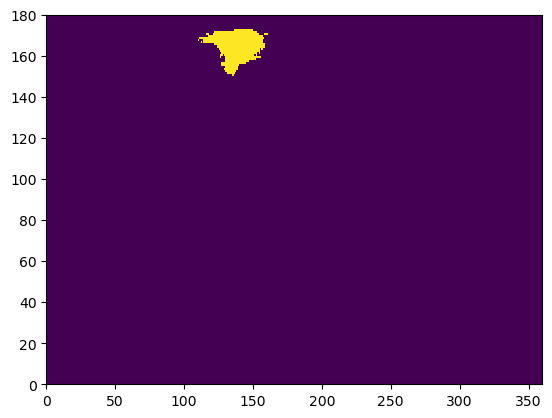

In [5]:
plt.pcolormesh(greenland)

In [6]:
n_lat, n_lon = greenland.shape

# 90N-90S at 1-deg resolution has 180 rows; 84N-84S has 168 rows (84 to -84 step -1 -> 169 actually)
# so check the exact row count you have before assuming 6 rows per side
n_pad_total = 180 - n_lat
assert n_pad_total % 2 == 0, "asymmetric padding needed — check exact lat bounds"
n_pad = n_pad_total // 2   # rows to add on EACH side (6 if 168 -> 180)

# If row 0 is 84N (i.e. lat descends from north to south, matching ds.lat[::-1]):
greenland_full = np.pad(greenland, ((n_pad, n_pad), (0, 0)),
                        mode='constant', constant_values=0)
print(greenland_full.shape)

(180, 360)


In [7]:
# ── Greenland-mean spectra: helpers for monthly / seasonal / annual periods ───
import re
from functools import lru_cache
from pathlib import Path

import numpy as np
import xarray as xr
import plotly.graph_objects as go
from plotly.subplots import make_subplots

DATA_DIR  = Path('../data')
MASK_FILE = DATA_DIR / 'GRE_mask.npy'
SAT       = 1                              # sat{#}_{mmyy}.zarr

H, C, KB      = 6.626e-34, 2.998e8, 1.381e-23
HIGHLIGHT_IDX = [12, 24, 30, 32]           # channels available on the maps
MONTH_ABBR    = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
SEASONS       = {'DJF': (12, 1, 2), 'MAM': (3, 4, 5),
                 'JJA': (6, 7, 8),  'SON': (9, 10, 11)}


def planck_um(lam_um, T):
    """Spectral radiance in W/m²/sr/μm for wavelength in μm."""
    lam = np.asarray(lam_um, dtype=float) * 1e-6
    return (2 * H * C**2 / lam**5) / np.expm1(H * C / (lam * KB * T)) * 1e-6


def brightness_temp_um(lam_um, B):
    """Invert Planck. lam_um in μm, B in W/m²/sr/μm. Returns T in K."""
    lam  = np.asarray(lam_um, dtype=float) * 1e-6
    B_si = np.asarray(B, dtype=float) * 1e6                 # → W/m²/sr/m
    ok   = np.isfinite(B_si) & (B_si > 0)                   # guard the log
    with np.errstate(invalid='ignore', divide='ignore'):
        T = (H * C / (lam * KB)) / np.log1p(
            2 * H * C**2 / (lam**5 * np.where(ok, B_si, 1.0)))
    return np.where(ok, T, np.nan)


# ── which months a request covers, and which files exist ─────────────────────
def month_file(year, month, sat=SAT):
    return DATA_DIR / f'sat{sat}_{month:02d}{year % 100:02d}.zarr'


def available_months(sat=SAT):
    """Sorted [(year, month), ...] actually present on disk."""
    found = []
    for p in DATA_DIR.glob(f'sat{sat}_*.zarr'):
        m = re.fullmatch(rf'sat{sat}_(\d{{2}})(\d{{2}})', p.stem)
        if m:
            found.append((2000 + int(m.group(2)), int(m.group(1))))
    return sorted(found)


def _full_year(y, period):
    """2-digit → 20yy. 4-digit must sit in 2000–2099: the filenames carry only
    yy, so e.g. 1225 and 2025 would address the same files."""
    year = y if y > 99 else 2000 + y
    if not 2000 <= year <= 2099:
        raise ValueError(f'{period!r}: year {year} outside 2000–2099 — '
                         f'sat{{#}}_{{mmyy}} filenames carry only 2 digits')
    return year


def parse_period(kind, period):
    """Months a request covers, as [(year, month), ...].

    kind='monthly',  period='1225'  → Dec 2025            (mmyy, as in the filenames)
    kind='seasonal', period='DJF25' → Dec 2024–Feb 2025   (season labelled by its END year)
    kind='annual',   period='2025'  → Jan–Dec 2025
    """
    k, p = str(kind).strip().lower(), str(period).strip()

    if k in ('monthly', 'month'):
        if not re.fullmatch(r'\d{1,4}', p):
            raise ValueError(f"monthly period must be mmyy, e.g. '1225' — got {period!r}")
        p = f'{int(p):04d}'                                  # 125 → '0125'
        month, yy = int(p[:2]), int(p[2:])
        if not 1 <= month <= 12:
            raise ValueError(f'month {month} out of range in {period!r}')
        return [(2000 + yy, month)]

    if k in ('seasonal', 'season'):
        m = re.fullmatch(r'([A-Za-z]{3})(\d{2}|\d{4})', p)
        if not m or m.group(1).upper() not in SEASONS:
            raise ValueError(f"seasonal period must be e.g. 'DJF25' — got {period!r}")
        season = m.group(1).upper()
        year   = _full_year(int(m.group(2)), period)         # season's END year
        # Dec belongs to the previous calendar year: DJF25 = 2024-12, 2025-01, 2025-02
        return [(year - 1 if mo == 12 else year, mo) for mo in SEASONS[season]]

    if k in ('annual', 'ann', 'year', 'yearly'):
        if not re.fullmatch(r'\d{2}|\d{4}', p):
            raise ValueError(f"annual period must be a year, e.g. '2025' — got {period!r}")
        return [(_full_year(int(p), period), mo) for mo in range(1, 13)]

    raise ValueError(f"kind must be 'monthly', 'seasonal' or 'annual' — got {kind!r}")


def missing_months(kind, period, sat=SAT):
    """['2024-12', ...] for requested months with no file on disk (does not raise)."""
    return [f'{y}-{m:02d}' for y, m in parse_period(kind, period)
            if not month_file(y, m, sat).exists()]


# ── region mask, padded onto the data grid (same recipe as the map above) ─────
_MASK_CACHE = {}

def greenland_mask(ds):
    key = (ds.sizes['lat'], ds.sizes['lon'])
    if key not in _MASK_CACHE:
        m = np.load(MASK_FILE)
        n_pad = ds.sizes['lat'] - m.shape[0]
        assert n_pad % 2 == 0, 'asymmetric padding needed — check exact lat bounds'
        m = np.pad(m, ((n_pad // 2, n_pad // 2), (0, 0)), constant_values=0)
        _MASK_CACHE[key] = m.astype(bool)
    return xr.DataArray(_MASK_CACHE[key], dims=('lat', 'lon'),
                        coords={'lat': ds.lat, 'lon': ds.lon}, name='greenland_mask')


# ── stage 1: cells → one monthly mean ────────────────────────────────────────
@lru_cache(maxsize=None)          # seasons/annual reuse these; .cache_clear() if files change
def month_spectrum(year, month, sat=SAT, mask_fn=greenland_mask):
    """Count-weighted mean spectrum over the masked cells of a single month.

    Each cell already holds a mean/std/count over its own observations, so cells
    pool by count:
        n  = Σᵢ nᵢ,   μ = Σᵢ nᵢmᵢ / n,   σ² = Σᵢ nᵢ(sᵢ² + mᵢ²)/n − μ²
    """
    f = month_file(year, month, sat)
    if not f.exists():
        raise FileNotFoundError(f'{f} not found — {MONTH_ABBR[month - 1]} {year} is missing')

    ds   = xr.open_zarr(f)
    mask = mask_fn(ds)

    cnt  = ds.spectral_radiance_count.where(mask, 0).fillna(0)
    mean = ds.spectral_radiance.where(mask)
    std  = ds.spectral_radiance_std.where(mask)
    good = (cnt > 0) & np.isfinite(mean)

    cnt  = cnt.where(good, 0).astype('float64')
    mean = mean.where(good, 0.0)
    std  = std.where(good, 0.0).fillna(0.0)          # std is NaN where count == 1

    n    = cnt.sum(('lat', 'lon'))
    n_ok = n.where(n > 0)
    mu   = (cnt * mean).sum(('lat', 'lon')) / n_ok
    var  = ((cnt * (std**2 + mean**2)).sum(('lat', 'lon')) / n_ok - mu**2).clip(min=0)

    return xr.Dataset(dict(wavelength=ds.wavelength,
                           radiance=mu.rename('radiance'),
                           std=np.sqrt(var).rename('std'),
                           count=n.rename('count')))


# ── stage 2: monthly means → period mean ─────────────────────────────────────
def region_spectrum(kind, period, sat=SAT, mask_fn=greenland_mask):
    """Mean spectrum over the masked region for one monthly/seasonal/annual period.

    Two-stage: every month is reduced to its own regional mean first
    (month_spectrum), then those monthly means are averaged with EQUAL weight, so
    a month with more overpasses cannot pull the seasonal/annual mean toward
    itself:
        μ = (1/M) Σₘ μₘ,   σ² = (1/M) Σₘ (σₘ² + μₘ²) − μ²
    Every requested month must be on disk — an incomplete period raises rather
    than averaging over what happens to be there.
    """
    months  = parse_period(kind, period)
    absent  = missing_months(kind, period, sat)
    if absent:
        raise FileNotFoundError(
            f'{kind} {period}: no data for {", ".join(absent)} — '
            f'refusing to average an incomplete period')

    labels  = [f'{y}-{m:02d}' for y, m in months]
    monthly = xr.concat([month_spectrum(y, m, sat, mask_fn) for y, m in months],
                        dim=xr.DataArray(labels, dims='month', name='month'))

    mu_m = monthly.radiance
    mean = mu_m.mean('month')                                    # equal weight per month
    var  = ((monthly['std']**2 + mu_m**2).mean('month') - mean**2).clip(min=0)

    spec = xr.Dataset(dict(wavelength=monthly.wavelength.isel(month=0, drop=True),
                           radiance=mean.rename('radiance'),
                           std=np.sqrt(var).rename('std'),
                           count=monthly['count'].sum('month').rename('count'),
                           radiance_monthly=mu_m.rename('radiance_monthly')))
    spec.attrs.update(months_used=labels, n_months=len(labels),
                      kind=str(kind).lower(), period=str(period))
    return spec


def period_label(kind, period):
    """'Dec 2025' / 'DJF 2024/25' / 'Annual 2025'."""
    months = parse_period(kind, period)
    k      = str(kind).strip().lower()
    if k in ('monthly', 'month'):
        y, m = months[0]
        return f'{MONTH_ABBR[m - 1]} {y}'
    if k in ('seasonal', 'season'):
        season = re.fullmatch(r'([A-Za-z]{3})(\d{2}|\d{4})', str(period).strip()).group(1).upper()
        y0, y1 = months[0][0], months[-1][0]
        return f'{season} {y0}/{y1 % 100:02d}' if y0 != y1 else f'{season} {y1}'
    return f'Annual {months[0][0]}'


def spectrum_for(kind, period, sat=SAT):
    """(spectrum, label) for one period. Raises if any of its months is missing."""
    return region_spectrum(kind, period, sat=sat), period_label(kind, period)


# ── plotting ─────────────────────────────────────────────────────────────────
def _bar_widths(wl, cap=1.2, frac=0.95):
    """Bar width per channel from the gaps to its neighbours."""
    d = np.diff(wl)
    w = np.empty_like(wl)
    w[0], w[-1] = d[0], d[-1]
    w[1:-1] = np.maximum(np.minimum(d[1:], cap), np.minimum(d[:-1], cap))
    return w * frac


def _period_traces(spec, label):
    """The five traces of one period, plus the title they belong under."""
    wl, rad = spec.wavelength.values, spec.radiance.values
    sd, cnt = spec['std'].values, spec['count'].values

    # drop channels with no wavelength label OR no radiance
    valid = np.isfinite(wl) & np.isfinite(rad)
    idx   = np.where(valid)[0]
    wl_v, rad_v, sd_v, cnt_v = wl[valid], rad[valid], sd[valid], cnt[valid]

    peak_i   = int(np.nanargmax(rad_v))
    peak_lam = float(wl_v[peak_i])
    peak_rad = float(rad_v[peak_i])
    T_peak   = float(brightness_temp_um(peak_lam, peak_rad))

    widths = _bar_widths(wl_v)
    hl     = np.isin(idx, HIGHLIGHT_IDX)                  # highlighted channels
    hover  = np.stack([idx.astype(float), cnt_v], axis=1)  # [channel, n obs]
    bar_hover = ('Channel %{customdata[0]:.0f}<br>λ = %{x:.3f} μm<br>'
                 'L = %{y:.4f} W/m²/sr/μm<br>n = %{customdata[1]:,.0f}<extra></extra>')
    lam_dense = np.linspace(wl_v.min(), wl_v.max(), 500)

    traces = [
        (go.Bar(x=wl_v[hl], y=rad_v[hl], width=widths[hl],
                name='Channels available on maps', marker_color='crimson',
                customdata=hover[hl], hovertemplate=bar_hover), 1),
        (go.Bar(x=wl_v[~hl], y=rad_v[~hl], width=widths[~hl],
                name='Other channels', marker_color='darkorange',
                customdata=hover[~hl], hovertemplate=bar_hover), 1),
        (go.Scatter(x=lam_dense, y=planck_um(lam_dense, T_peak), mode='lines',
                    name=f'Planck B(λ, {T_peak:.1f} K)',
                    line=dict(color='tomato', dash='dash', width=2),
                    hovertemplate='λ = %{x:.3f} μm<br>B = %{y:.4f} W/m²/sr/μm<extra></extra>'), 1),
        (go.Scatter(x=[peak_lam], y=[peak_rad], mode='markers',
                    name=f'Peak: {peak_lam:.2f} μm, T_b = {T_peak:.1f} K',
                    marker=dict(color='crimson', size=12, symbol='star',
                                line=dict(color='black', width=1)),
                    hovertemplate=(f'Peak channel<br>λ = {peak_lam:.3f} μm<br>'
                                   f'L = {peak_rad:.4f} W/m²/sr/μm<br>'
                                   f'T_b = {T_peak:.2f} K<extra></extra>')), 1),
        (go.Bar(x=wl_v, y=sd_v, width=widths,
                marker_color=np.where(hl, 'crimson', 'deepskyblue'),
                name='Std', showlegend=False, customdata=hover,
                hovertemplate=('Channel %{customdata[0]:.0f}<br>λ = %{x:.3f} μm<br>'
                               'σ = %{y:.4f} W/m²/sr/μm<extra></extra>')), 2),
    ]

    n_mon = spec.attrs['n_months']
    how   = '1 month' if n_mon == 1 else f'mean of {n_mon} monthly means'
    title = (f'Greenland mean spectral radiance — {label}'
             f'   (peak {peak_lam:.2f} μm, T_b = {T_peak:.1f} K, '
             f'{how}, n = {np.nansum(cnt_v):,.0f} obs)')
    return traces, title


def plot_spectra(periods, out_html=None, show=True):
    """Radiance bars + Planck fit (row 1) and pooled std (row 2).

    periods: [(spectrum, label), ...] as returned by spectrum_for(). One entry
    draws a single figure; several add a dropdown to switch between them.
    """
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.07,
                        row_heights=[0.68, 0.32],
                        subplot_titles=('Spectral Radiance', 'Std of Spectral Radiance'))

    titles, blocks = [], []
    for k, (spec, label) in enumerate(periods):
        traces, title = _period_traces(spec, label)
        titles.append(title)
        start = len(fig.data)
        for tr, row in traces:
            tr.visible = (k == 0)                 # only the first period shows
            fig.add_trace(tr, row=row, col=1)
        blocks.append((start, len(fig.data)))

    multi = len(periods) > 1
    fig.update_yaxes(title_text='Spectral radiance (W/m²/sr/μm)', row=1, col=1)
    fig.update_yaxes(title_text='σ (W/m²/sr/μm)', row=2, col=1)
    fig.update_xaxes(title_text='Wavelength (μm)', row=2, col=1)
    fig.update_layout(
        title=dict(text=titles[0], x=0.06, y=0.985, yanchor='top'),
        margin=dict(l=0, r=0, t=120 if multi else 80, b=40),   # room for the dropdown
        bargap=0, height=700,
        legend=dict(x=0.98, y=0.90, xanchor='right', yanchor='bottom',
                    entrywidth=200, entrywidthmode='pixels'),
    )

    if multi:
        n_traces = len(fig.data)
        buttons  = [dict(label=periods[k][1], method='update',
                         args=[{'visible': [lo <= i < hi for i in range(n_traces)]},
                               {'title.text': titles[k]}])
                    for k, (lo, hi) in enumerate(blocks)]
        fig.update_layout(updatemenus=[dict(          # sits under the title
            active=0, buttons=buttons, direction='down', showactive=True,
            x=0.0, xanchor='left', y=1.13, yanchor='top')])

    if out_html:
        fig.write_html(out_html)
    if show:
        fig.show()
    return fig

In [8]:
# ── every complete period one satellite has on disk ──────────────────────────
# request = (kind, period):  ('monthly', '1225') ('seasonal', 'DJF25') ('annual', '2025')
SAT_SEL = 2

avail = available_months(SAT_SEL)
years = sorted({y for y, _ in avail})
print(f'sat{SAT_SEL}: {len(avail)} months on disk, '
      f'{avail[0][0]}-{avail[0][1]:02d} → {avail[-1][0]}-{avail[-1][1]:02d}')

# seasons/years worth asking for: those with at least one month of data
seasons_wanted = [f'{s}{y % 100:02d}' for y in range(years[0], years[-1] + 2) for s in SEASONS]
requests = ([('monthly',  f'{m:02d}{y % 100:02d}') for y, m in avail]
            + [('seasonal', p) for p in seasons_wanted
               if any(ym in avail for ym in parse_period('seasonal', p))]
            + [('annual',   str(y)) for y in years])

periods = []
for kind, period in requests:
    absent = missing_months(kind, period, SAT_SEL)   # region_spectrum would raise on these
    if absent:
        shown = ', '.join(absent[:3]) + (f' (+{len(absent) - 3} more)' if len(absent) > 3 else '')
        print(f'  ! {kind:8} {period:6} not plotted — missing {shown}')
        continue
    periods.append(spectrum_for(kind, period, SAT_SEL))

fig = plot_spectra(periods, out_html=f'../gallery/greenland/spectra_sat{SAT_SEL}.html')

# peak channel per period, for the record
for spec, label in periods:
    wl, rad = spec.wavelength.values, spec.radiance.values
    v       = np.isfinite(wl) & np.isfinite(rad)
    i       = int(np.nanargmax(rad[v]))
    print(f'{label:>12}   λ_peak = {wl[v][i]:6.2f} μm   '
          f'L = {rad[v][i]:.3f} W/m²/sr/μm   '
          f'T_b = {float(brightness_temp_um(wl[v][i], rad[v][i])):6.2f} K   '
          f'[{spec.attrs["n_months"]} mo]')

sat2: 23 months on disk, 2024-06 → 2026-04
  ! seasonal MAM26  not plotted — missing 2026-05
  ! annual   2024   not plotted — missing 2024-01, 2024-02, 2024-03 (+2 more)
  ! annual   2026   not plotted — missing 2026-05, 2026-06, 2026-07 (+5 more)


    Jun 2024   λ_peak =  10.98 μm   L = 4.487 W/m²/sr/μm   T_b = 255.87 K   [1 mo]
    Jul 2024   λ_peak =  10.98 μm   L = 4.811 W/m²/sr/μm   T_b = 259.37 K   [1 mo]
    Aug 2024   λ_peak =  10.98 μm   L = 4.524 W/m²/sr/μm   T_b = 256.27 K   [1 mo]
    Sep 2024   λ_peak =  10.98 μm   L = 4.109 W/m²/sr/μm   T_b = 251.57 K   [1 mo]
    Oct 2024   λ_peak =  10.98 μm   L = 4.476 W/m²/sr/μm   T_b = 255.74 K   [1 mo]
    Nov 2024   λ_peak =  11.80 μm   L = 3.393 W/m²/sr/μm   T_b = 241.87 K   [1 mo]
    Dec 2024   λ_peak =  11.80 μm   L = 2.963 W/m²/sr/μm   T_b = 235.57 K   [1 mo]
    Jan 2025   λ_peak =  11.80 μm   L = 2.935 W/m²/sr/μm   T_b = 235.15 K   [1 mo]
    Feb 2025   λ_peak =  11.80 μm   L = 3.264 W/m²/sr/μm   T_b = 240.04 K   [1 mo]
    Mar 2025   λ_peak =  11.80 μm   L = 3.143 W/m²/sr/μm   T_b = 238.28 K   [1 mo]
    Apr 2025   λ_peak =  11.80 μm   L = 3.533 W/m²/sr/μm   T_b = 243.81 K   [1 mo]
    May 2025   λ_peak =  11.80 μm   L = 4.033 W/m²/sr/μm   T_b = 250.40 K   [1 mo]
    